<a href="https://colab.research.google.com/github/vinothkumard2006-ai/Practice-in-colab/blob/main/AI%20vs%20Human%20text%20classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.listdir('/content/drive/MyDrive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['Untitled spreadsheet.gsheet',
 'job survey.gsheet',
 'final_combined_enriched_v4.csv',
 'Colab Notebooks',
 'Medicinal plant dataset',
 'data_for_preprocessing.csv']

In [79]:
# =========================
# 1. Import Libraries
# =========================
import re
import pandas as pd
import nltk
import numpy as np

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Downloads
nltk.download('punkt')# tokenization
nltk.download('stopwords')# remove useless words
nltk.download('wordnet')# Lemmatization
nltk.download('omw-1.4')# support for wordnet

# =========================
# 2. Load Data
# =========================
# Your dataset
# df_preprocessing must have: Text, Author
Data = pd.read_csv('/content/drive/MyDrive/data_for_preprocessing.csv')

# =========================
# 3. Initialize
# =========================
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# =========================
# 4. NLP Pipeline Function
# =========================
def preprocess(text):

    # Sentence Segmentation
    sentences = sent_tokenize(str(text))

    final_words = []

    for sentence in sentences:

        # Lowercase
        sentence = sentence.lower()

        # Remove symbols
        sentence = re.sub(r'[^a-zA-Z\s]', '', sentence)

        # Tokenization
        words = word_tokenize(sentence)

        # Remove stopwords + Lemmatization
        words = [
            lemmatizer.lemmatize(word)
            for word in words
            if word not in stop_words
        ]

        final_words.extend(words)

    return " ".join(final_words)

# =========================
# 5. Apply Preprocessing
# =========================
Data['clean_text'] = Data['Text'].apply(preprocess)

# =========================
# 6. Convert Words → Vectors (TF-IDF)
# =========================
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(Data['clean_text'])

# Encode labels (AI=1, Human=0)
y = Data['Author'].map({'AI': 1, 'Human': 0})

# =========================
# 7. Train/Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,shuffle=True, random_state=42
)

# =========================
# 8. Train ML Model
# =========================
model = LogisticRegression()
model.fit(X_train, y_train)

# =========================
# 9. Prediction
# =========================
y_pred = model.predict(X_test)

# =========================
# 10. Evaluation
# =========================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Accuracy: 0.9744645799011532

Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       575
           1       0.97      0.99      0.98       639

    accuracy                           0.97      1214
   macro avg       0.98      0.97      0.97      1214
weighted avg       0.97      0.97      0.97      1214



Evaluation Metrices for classification

Accuracy: 0.9744645799011532
Precision: 0.9662576687116564
Recall: 0.9859154929577465
F1 Score: 0.975987606506584

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       575
           1       0.97      0.99      0.98       639

    accuracy                           0.97      1214
   macro avg       0.98      0.97      0.97      1214
weighted avg       0.97      0.97      0.97      1214


Confusion Matrix:
 [[553  22]
 [  9 630]]

ROC AUC Score: 0.9978063550384433


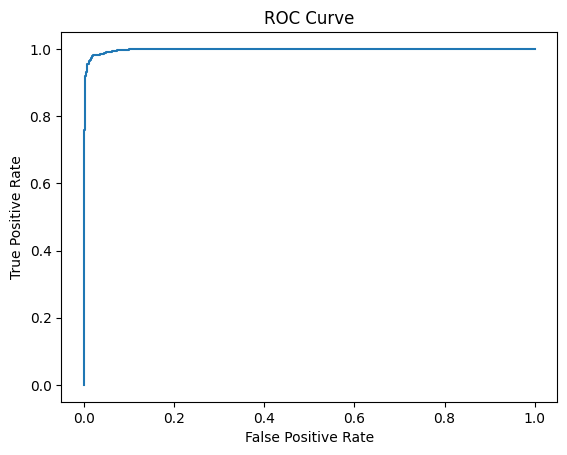

In [80]:
# =========================
# Import Libraries
# =========================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt

# =========================
# 1. Accuracy
# =========================
print("Accuracy:", accuracy_score(y_test, y_pred))

# =========================
# 2. Precision
# =========================
print("Precision:", precision_score(y_test, y_pred))

# =========================
# 3. Recall
# =========================
print("Recall:", recall_score(y_test, y_pred))

# =========================
# 4. F1 Score
# =========================
print("F1 Score:", f1_score(y_test, y_pred))

# =========================
# 5. Classification Report
# =========================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# =========================
# 6. Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# =========================
# 7. ROC Curve + AUC
# =========================
# Get probability scores
y_prob = model.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)
print("\nROC AUC Score:", auc_score)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()